# Notebook 3 — Keras Utility-Based Pipeline

In [1]:
print("python")

python


In [2]:
#%load_ext autotime
import tensorflow as tf
print("TF Version:", tf.__version__)
print("Devices:", tf.config.list_physical_devices())

TF Version: 2.20.0
Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

In [11]:
PROJECT_ROOT = ".."
RAW_DIR = os.path.join(PROJECT_ROOT, "data", "raw", "images_dataSAT")
dir_agri = os.path.join(RAW_DIR, "class_1_agri")
dir_non_agri = os.path.join(RAW_DIR, "class_0_non_agri")
(dir_agri, dir_non_agri)

('..\\data\\raw\\images_dataSAT\\class_1_agri',
 '..\\data\\raw\\images_dataSAT\\class_0_non_agri')

* Load data: `image_dataset_from_directory`
  * auto labels + 80/20 split
  * resize (64×64), batch = 8
* Inspect: class names + visualize batch
* Augment: `RandomFlip` + `RandomRotation` via `.map()`
* Optimize: `.cache().prefetch(AUTOTUNE)`

In [12]:
IMAGE_SIZE = (64, 64)
BATCH_SIZE = 8

In [13]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    RAW_DIR,
    labels='inferred',          
    label_mode='int',           
    validation_split=0.2,       
    subset='training',          
    seed=1337,                  # Shuffle seed for reproducible splits
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 6000 files belonging to 2 classes.
Using 4800 files for training.


In [14]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    RAW_DIR,
    labels='inferred',
    label_mode='int',
    validation_split=0.2,
    subset='validation',
    seed=1337,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

Found 6000 files belonging to 2 classes.
Using 1200 files for validation.


Class names inferred by Keras: ['class_0_non_agri', 'class_1_agri']


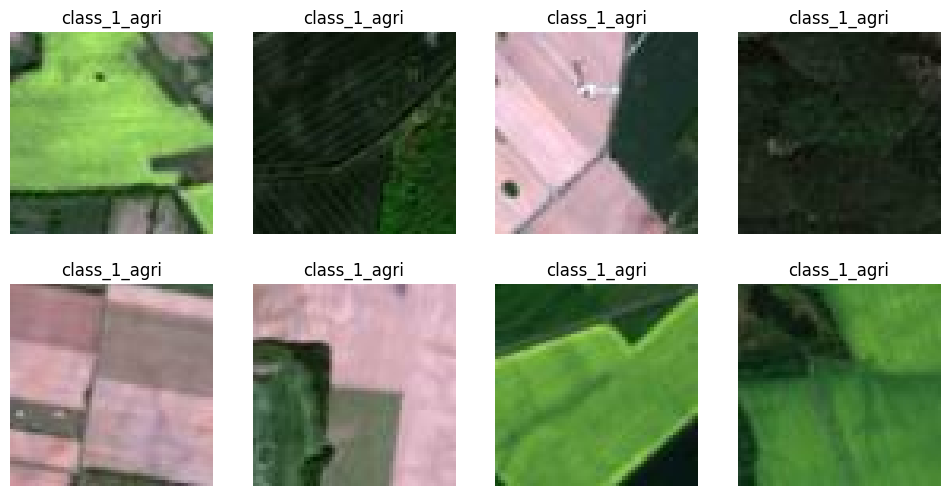

In [15]:
print(f"Class names inferred by Keras: {train_ds.class_names}")

plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1): 
    for i in range(BATCH_SIZE):
        ax = plt.subplot(2, 4, i + 1)
        # Images are loaded as float32, so we convert to uint8 for display
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

In [16]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
])

# Apply augmentation to the training dataset using map
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

# Configure for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Dataset is now configured for high performance!")

Dataset is now configured for high performance!
